# Online Simulation-Based Digital Twin: Nibelungenbrücke

This notebook presents an online simulation-based digital twin developed for the Nibelungenbrücke bridge. The system is managed by an orchestration layer that dynamically handles user inputs such as the type of physical model to analyze, the simulation time window, and spatial locations of interest. It supports both standard transient thermal simulations and simulations that incorporate uncertainty quantification (UQ), allowing users to assess not only predicted behavior but also confidence in those predictions. 

The simulations are powered by the FenicSXConcrete package and provide physics-based, real-time insights into the thermomechanical and structural deflection behavior of the bridge.


> ⚠️ **if the environment was not properly set up from the provided YAML file. <br> <br>Please run the following cell once before using the notebook to install all required packages in your JupyterHub environment**  

In [1]:
#import sys
#!{sys.executable} -m pip install git+https://github.com/BAMresearch/FenicsXConcrete pint gmsh pytest jsonschema pandas pyproj tqdm pvlib meshio chaospy==3.3.9


#!{sys.executable} -m pip install git+https://github.com/BAMresearch/FenicsXConcrete@my-grf git+https://github.com/BAMresearch/probeye chaospy==3.3.9 doit==0.36.0 pint==0.24.4 jinja2==3.1.6 pdf2image==1.17.0 pint==0.24.4 pytest==8.4.0 jsonschema==4.24.0 pandas==2.3.0 pyproj tqdm pvlib==0.13.0 meshio python-gmsh==4.12.2 git

This code snippet adjusts the current working directory and updates the system path to ensure proper resolution of local project modules.

In [2]:
import os
import sys

original_cwd = os.getcwd()
root_dir = os.getcwd()
orchestrator_dir = os.path.join(root_dir, 'nibelungenbruecke', 'scripts', 'digital_twin_orchestrator')
os.chdir(orchestrator_dir)
sys.path.insert(0, root_dir)

from nibelungenbruecke.scripts.digital_twin_orchestrator.orchestrator import Orchestrator

### Definition of input parameters

This dictionary defines the configuration for running a digital twin simulation, including model selection, temporal settings, sensor definitions, and simulation options.

In [3]:
simulation_parameters = {
    'simulation_name': 'TestSimulation',
    'model': '3D_TransientThermal_1',
    'model_info': {
                    'type': '3D', 
                    'path': ''
                    },
    'data_source': 'OpenMeteo', # or 'MKP'
    'start_time': '2023-08-11T08:00:00Z',
    'end_time': '2023-09-11T16:10:00Z',
    'time_step': '250min',
    'virtual_sensor_positions': [
        {'x': 0.0, 'y': 0.0, 'z': 0.0, 'name': 'Sensor1'},
        {'x': 1.0, 'y': 0.0, 'z': 0.0, 'name': 'Sensor2'},
        {'x': 1.78, 'y': 0.0, 'z': 26.91, 'name': 'Sensor3'},
        {'x': -1.83, 'y': 0.0, 'z': 0.0, 'name': 'Sensor4'}
    ],
    'plot_pv': True,
    'full_field_results': True, # Set to True if you want full field results, the simulation will take longer and the results will be larger.
    'uncertainty_quantification': False, # Set to True if you want uncertainty quantification, the simulation will take longer and the results will be larger.
}

The `Orchestrator` class serves as the central controller responsible for managing the full digital twin simulation workflow. It orchestrates the configuration, model selection, simulation execution, and optional post-processing steps based on the input parameters defined earlier.

The following line initializes an instance of the `Orchestrator` with the user-defined configuration:

In [4]:
orchestrator = Orchestrator(simulation_parameters)

Provide your key to MKP's API to registers it with the Orchestrator instance:

In [5]:
if simulation_parameters["data_source"] == "MKP":
    key=input("\nEnter the code to connect API: ").strip()
elif simulation_parameters["data_source"] == "OpenMeteo":
    key = ""
else:
    raise "Wrong data source!"

orchestrator.set_api_key(key)

In [6]:
#orchestrator.load(simulation_parameters)

Before proceeding with the simulation, the Orchestrator verifies that the coordinates of the virtual sensors lie within the boundaries of the mesh domain. It removes any sensors specified in the simulation_parameters that fall outside the domain before continuing.

And the simulation is executed using:

In [7]:
results = orchestrator.run()

Info    : Reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'...
Info    : 2443 entities
Info    : 2197 nodes
Info    : 12920 elements
Info    : Done reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'
Virtual Sensor1 is inside the domain.
Virtual Sensor2 is inside the domain.
Virtual Sensor3 is inside the domain.
Virtual Sensor4 is inside the domain.
Info    : Reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'...
Info    : 2443 entities
Info    : 2197 nodes
Info    : 12920 elements
Info    : Done reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'
Info    : Reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'...
Info    : 2443 entities
Info    : 

100%|██████████| 185/185 [01:18<00:00,  2.36it/s]

New model 'thermal_model' saved successfully.


### Results


Plotting all real sensors requested from MKP’s database together with their corresponding virtual sensors.

In [8]:
orchestrator.plot("plot_real_vs_virtual_sensors_together")

Plotting virtual sensors together

In [9]:
orchestrator.plot("plot_all_sensors_together")



The simulation results at the virtual sensor locations defined in `simulation_parameters` are visualized.

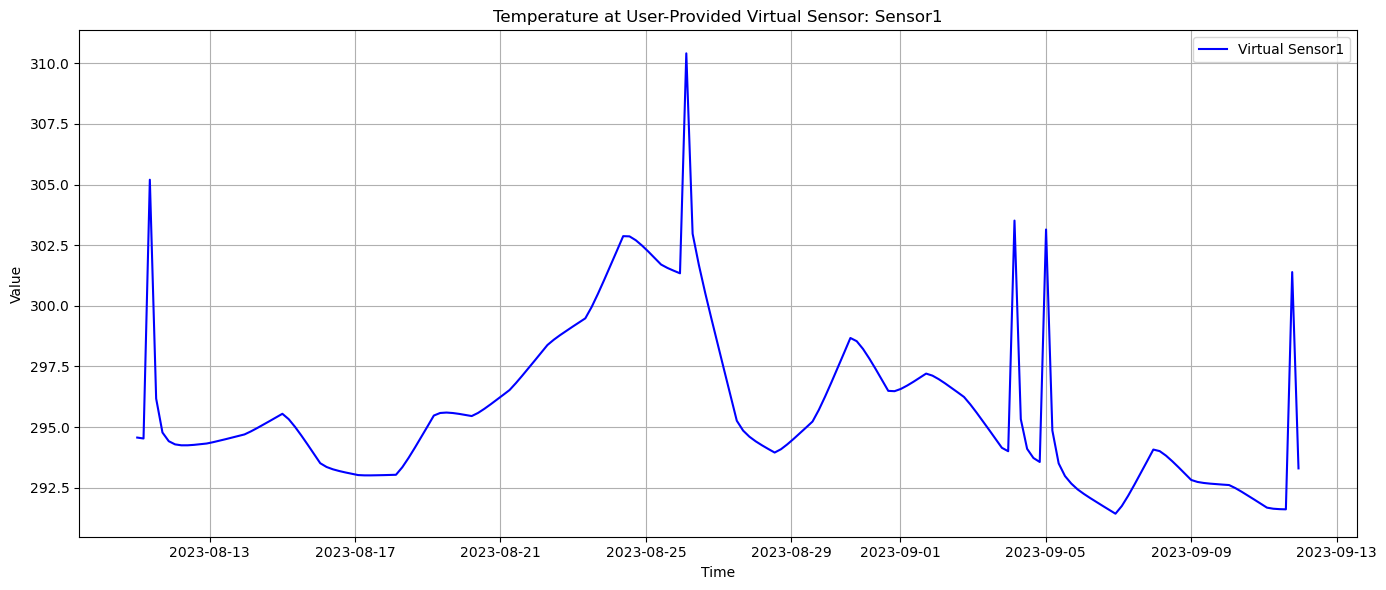

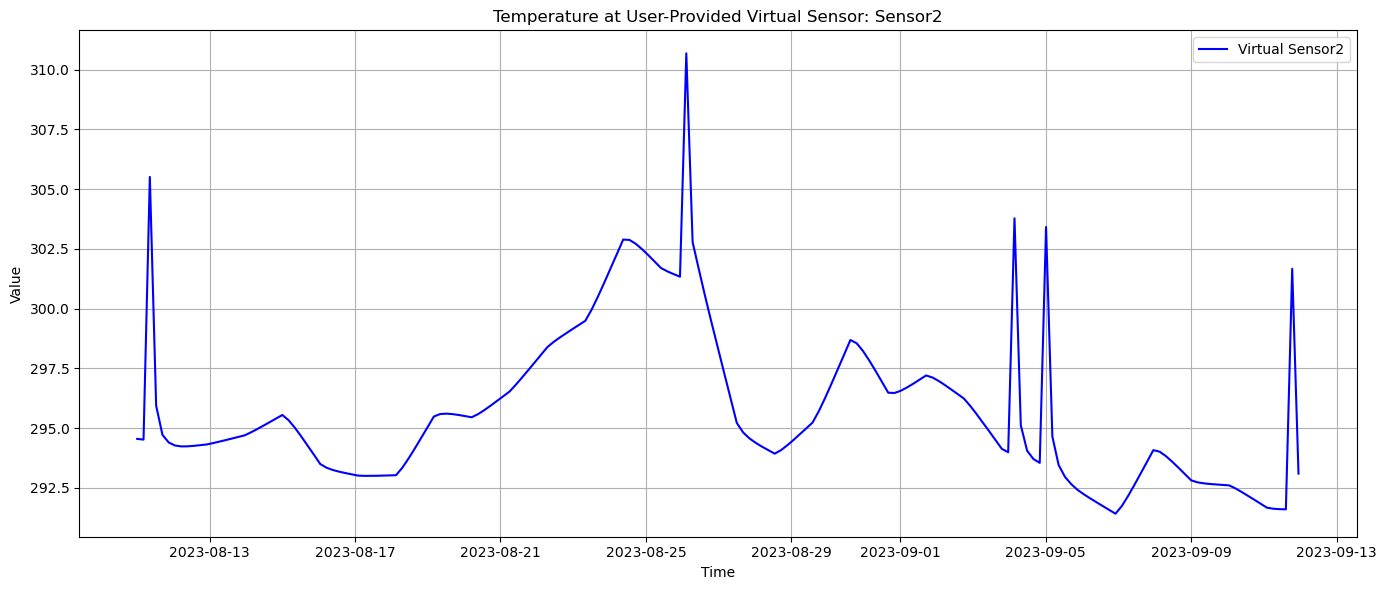

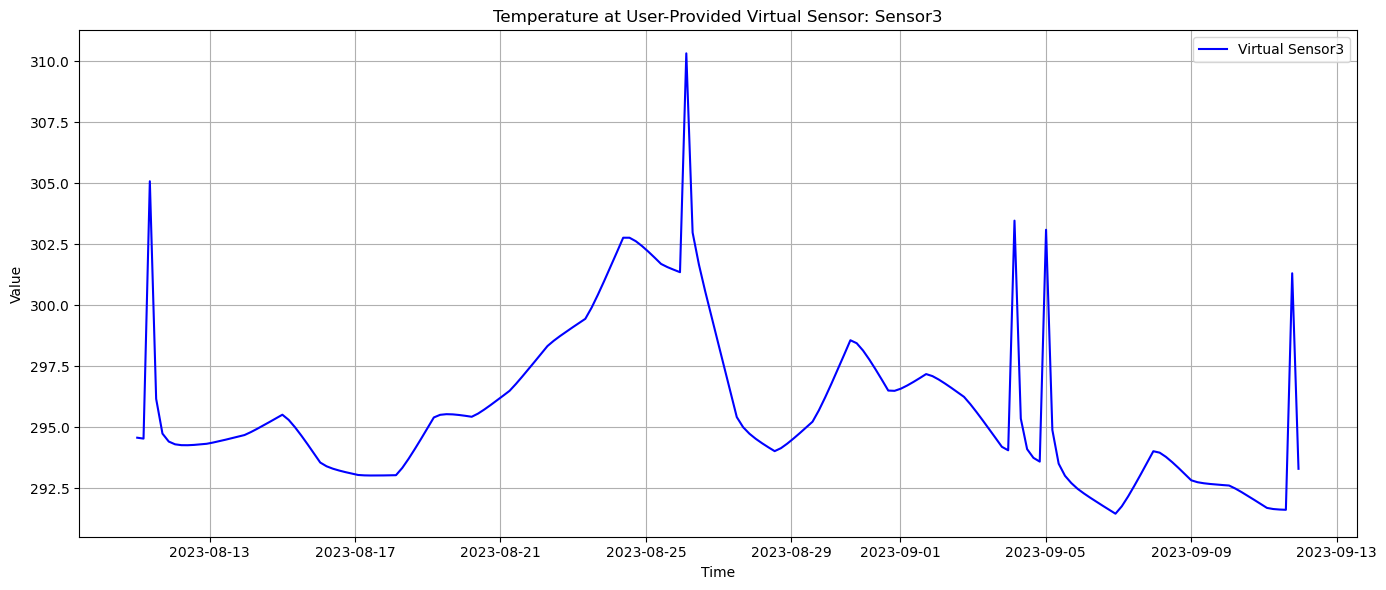

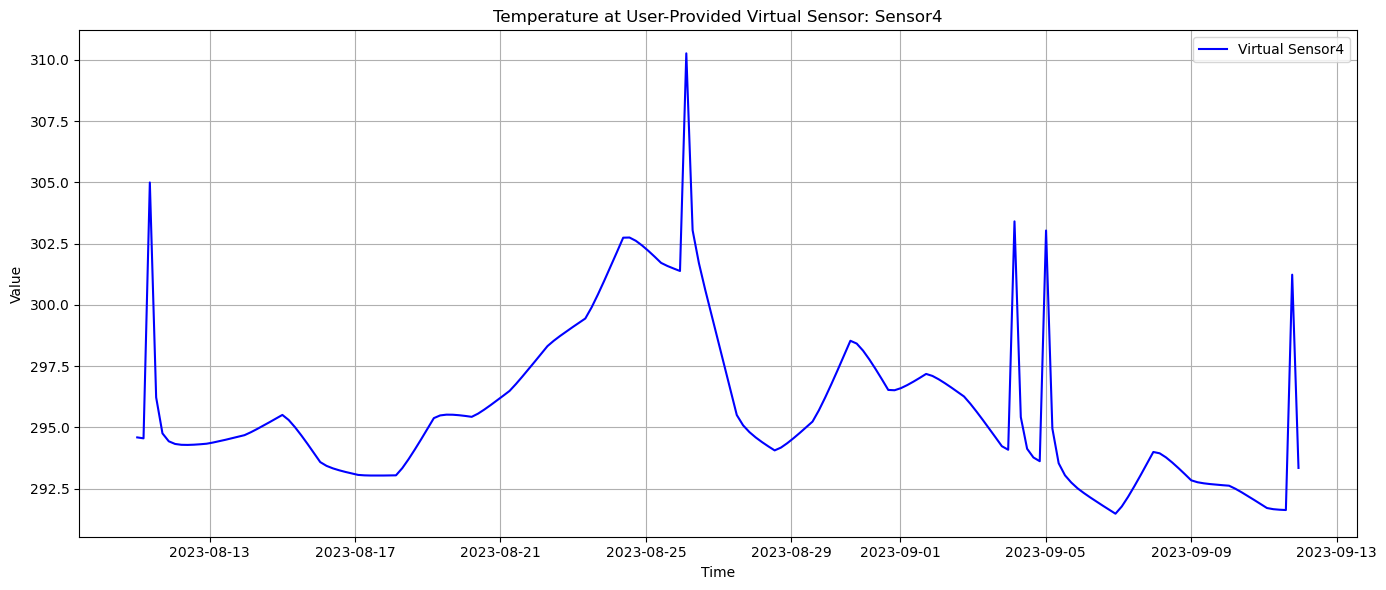

In [10]:
orchestrator.plot("plot_virtual_sensors")

***Model vs. Real Sensor Comparison***:  Plot comparing simulation results at virtual sensor locations with available real sensor measurements.

In [11]:
orchestrator.plot("plot_real_vs_virtual_sensors")

### Full-field response (3D)

The full-field simulation results can be reached with the following method.<br>

! Interactive visualization within the interface is not yet supported but will be introduced soon. Meanwhile files can be downloaded from the specified paths printed below.

In [12]:
orchestrator.plot("plot_full_field_response")

Please find the full-field response at the following paths:
  HDF5 file: NibelungenbrueckeDemonstrator/use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/output/paraview/Nibelungenbruecke_thermal.h5
  XDMF file: /NibelungenbrueckeDemonstrator/use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/output/paraview/Nibelungenbruecke_thermal.xdmf



### Thermal Model Uncertainty Quantification

Uncertainty quantification for the thermal model has been introduced. To enable this feature:  
- Set the parameter `uncertainty_quantification` to `True`  
- Ensure the parameter `plot_pv` is set to `False`  

This configuration activates the uncertainty analysis.

In [13]:
simulation_parameters = {
    'simulation_name': 'TestSimulation',
    'model': '3D_TransientThermal_1',
    'model_info': {
                    'type': '3D', 
                    'path': ''
                    },
    'data_source': 'MKP', # or ''
    'start_time': '2023-08-11T08:00:00Z',
    'end_time': '2023-09-13T08:10:00Z',
    'time_step': '250min',
    'virtual_sensor_positions': [
        {'x': 0.0, 'y': 0.0, 'z': 0.0, 'name': 'Sensor1'},
        {'x': 1.0, 'y': 0.0, 'z': 0.0, 'name': 'Sensor2'},
        {'x': 1.78, 'y': 0.0, 'z': 26.91, 'name': 'Sensor3'},
        {'x': -1.83, 'y': 0.0, 'z': 0.0, 'name': 'Sensor4'}
    ],
    'plot_pv': False,
    'full_field_results': True,
    'uncertainty_quantification': True,
}

Set the API key

In [ ]:
if simulation_parameters["data_source"] == "MKP":
    key=input("\nEnter the code to connect API: ").strip()
elif simulation_parameters["data_source"] == "OpenMeteo":
    key = ""
else:
    raise "Wrong data source!"

orchestrator.set_api_key(key)

Verify that all given virtual sensors fall within the mesh domain and then run the model.

In [14]:
#orchestrator.load(simulation_parameters)
orchestrator.run(simulation_parameters)

Info    : Reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'...
Info    : 2443 entities
Info    : 2197 nodes
Info    : 12920 elements
Info    : Done reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'
Virtual Sensor1 is inside the domain.
Virtual Sensor2 is inside the domain.
Virtual Sensor3 is inside the domain.
Virtual Sensor4 is inside the domain.
Info    : Reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'...
Info    : 2443 entities
Info    : 2197 nodes
Info    : 12920 elements
Info    : Done reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'
Info    : Reading '../../../use_cases/nibelungenbruecke_demonstrator_self_weight_fenicsxconcrete/input/models/mesh_3d_thermal.msh'...
Info    : 2443 entities
Info    : 

ValueError: Anfrage fehlgeschlagen mit Statuscode 401: 

Plotting all real sensors requested from MKP’s database together with their corresponding virtual sensors with uncertainty quantification.

In [ ]:
orchestrator.plot("plot_real_vs_virtual_sensors_together_with_UQ")

The simulation results at the virtual sensor locations defined in `simulation_parameters` are visualized below.

In [ ]:
orchestrator.plot("plot_all_sensors_together_with_UQ")

***Model vs. Real Sensor Comparison***:  Plot comparing simulation results at virtual sensor locations with available real sensor measurements.

In [ ]:
orchestrator.plot("plot_virtual_sensors_with_UQ")

In [ ]:
orchestrator.plot("plot_real_vs_virtual_sensors_with_UQ")

Plotting full-field response.
files can be downloaded from the path given below

In [ ]:
orchestrator.plot("plot_full_field_response")

In [ ]:
os.chdir(original_cwd)
print("Working directory restored to:", original_cwd)